2025-03-09 18:59:59: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-03-09 18:59:59: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-03-09 18:59:59: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-03-09 19:00:01: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-03-09 19:00:01: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-03-09 19:00:01: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-03-09 19:00:01: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-09 19:00:03: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-09 19:00:04: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-09 19:00:05: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-03-09 19:00:06: oggm.workf

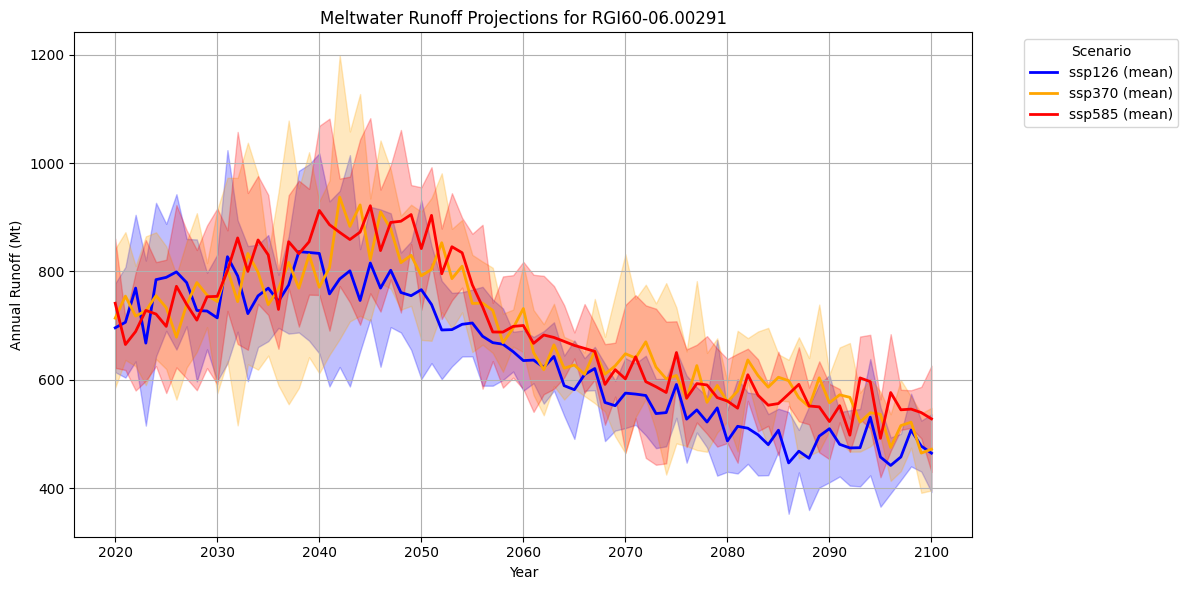

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# OGGM and utility libraries
import oggm.cfg as cfg
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
from oggm.shop import gcm_climate

# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_gcm_run', reset=True)

# Enable storing model geometry for run_with_hydro
cfg.PARAMS['store_model_geometry'] = True  # Required for run_with_hydro

# Define the glacier IDs
rgi_ids = ['RGI60-06.00291']

# Get the pre-processed glacier directories
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)

# Define the 5 GCMs and SSP scenarios 
gcms = [
    'gfdl-esm4_r1i1p1f1', 
    'mpi-esm1-2-hr_r1i1p1f1', 
    'mri-esm2-0_r1i1p1f1', 
    'ipsl-cm6a-lr_r1i1p1f1', 
    'ukesm1-0-ll_r1i1p1f2'
]
scenarios = ['ssp126', 'ssp370', 'ssp585']

# Download and process GCM data
for gcm in gcms:
    for ssp in scenarios:
        workflow.execute_entity_task(
            gcm_climate.process_monthly_isimip_data,
            gdirs, 
            ssp=ssp,
            member=gcm,
            output_filesuffix=f'_ISIMIP3b_{gcm}_{ssp}'
        )

# Perform a spinup based on historical data
ds_spinup = utils.compile_run_output(gdirs, input_filesuffix='_spinup_historical')

# Run projections with hydrological outputs
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        workflow.execute_entity_task(
            tasks.run_with_hydro, gdirs,
            run_task=tasks.run_from_climate_data,
            climate_filename='gcm_data',
            climate_input_filesuffix=rid,
            init_model_filesuffix='_spinup_historical',
            output_filesuffix=f'{rid}_hydro',
            store_monthly_hydro=True
        )

# Compile results for each GCM and SSP scenario
results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}_hydro'
        with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix=rid)) as ds:
            ds = ds.isel(time=slice(0, -1)).load()
            ds = ds.assign_coords(GCM=gcm, SCENARIO=ssp)
            results.append(ds)

# Combine all results into a single dataset
ds_total = xr.concat(results, dim='run')

# Select the variables relevant for runoff
runoff_vars = ['melt_off_glacier', 'melt_on_glacier', 'liq_prcp_off_glacier', 'liq_prcp_on_glacier']
# Convert to mega tonnes instead of kg
ds_total_runoff = ds_total[runoff_vars].clip(0) * 1e-9
# Sum the runoff variables along the time and run dimensions
ds_total_runoff = ds_total_runoff.to_array(dim='vars').sum(dim='vars')

# Calculate mean and standard deviation for each scenario
runoff_mean = ds_total_runoff.groupby('SCENARIO').mean(dim='run')
runoff_std = ds_total_runoff.groupby('SCENARIO').std(dim='run')

# Color dictionary for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Plot meltwater runoff changes with improved colors
fig, ax = plt.subplots(figsize=(12, 6))
for scenario in color_dict.keys():
    # Plot mean meltwater runoff
    ax.plot(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    # Add shaded region with colors that blend better
    ax.fill_between(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario) - runoff_std.sel(SCENARIO=scenario),
        runoff_mean.sel(SCENARIO=scenario) + runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.25  # Slightly lower alpha
    )

ax.set_ylabel('Annual Runoff (Mt)')
ax.set_xlabel('Year')
ax.set_title(f'Meltwater Runoff Projections for {gdirs[0].rgi_id}')
ax.grid(True)
ax.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()